✔  Dados carregados com sucesso.

── Nº de empresas com inovação ──
         setor    2008    2011    2014    2017
     Alimentos 11723.0 14013.0 13846.0 14362.0
       Bebidas   889.0   926.0   967.0  1043.0
      Químicos  3064.0  3517.0  3632.0  3509.0
Máq. Agrícolas     NaN   727.0   806.0   840.0

── Dispêndios em inovação (Mil R$) ──
         setor      2008      2011      2014      2017
     Alimentos 5823511.0 7814361.0 7106516.0 6398946.0
       Bebidas  894340.0 1273885.0 2152772.0 1042798.0
      Químicos 4279988.0 4583634.0 4748945.0 5879315.0
Máq. Agrícolas       NaN  523388.0  680082.0  418043.0

── Painel analítico (15 observações) ──
         setor  ano  n_empresas  dispendio_mil_reais
     Alimentos 2008     11723.0            5823511.0
       Bebidas 2008       889.0             894340.0
      Químicos 2008      3064.0            4279988.0
     Alimentos 2011     14013.0            7814361.0
       Bebidas 2011       926.0            1273885.0
      Químicos 2011     

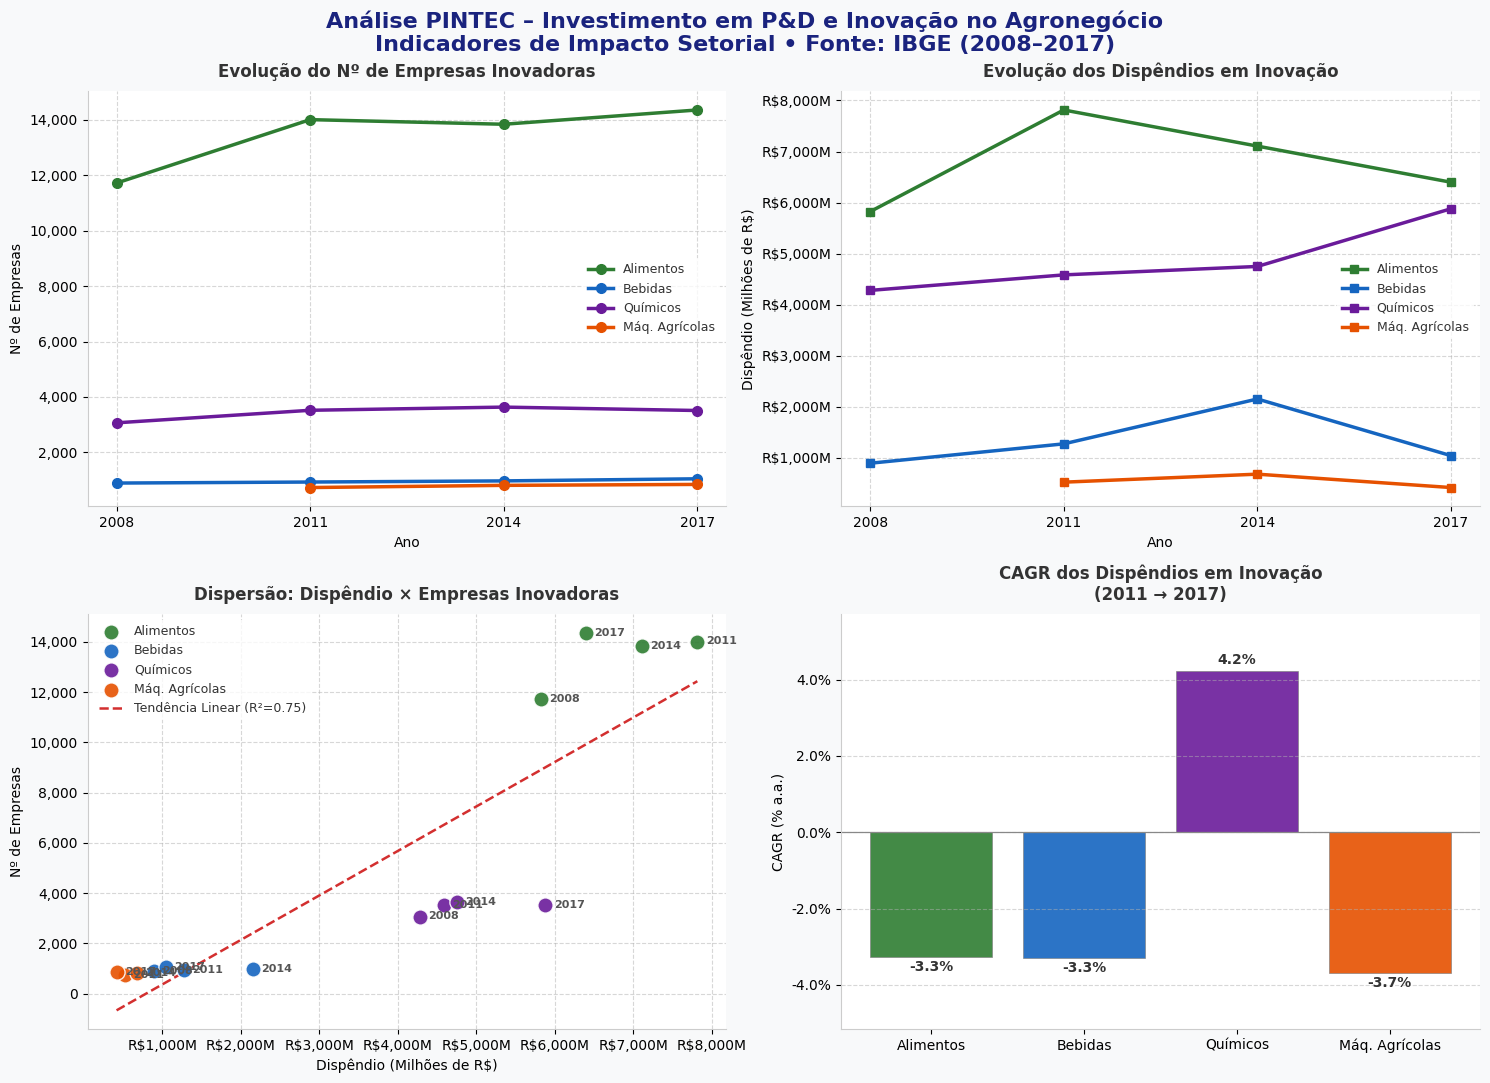

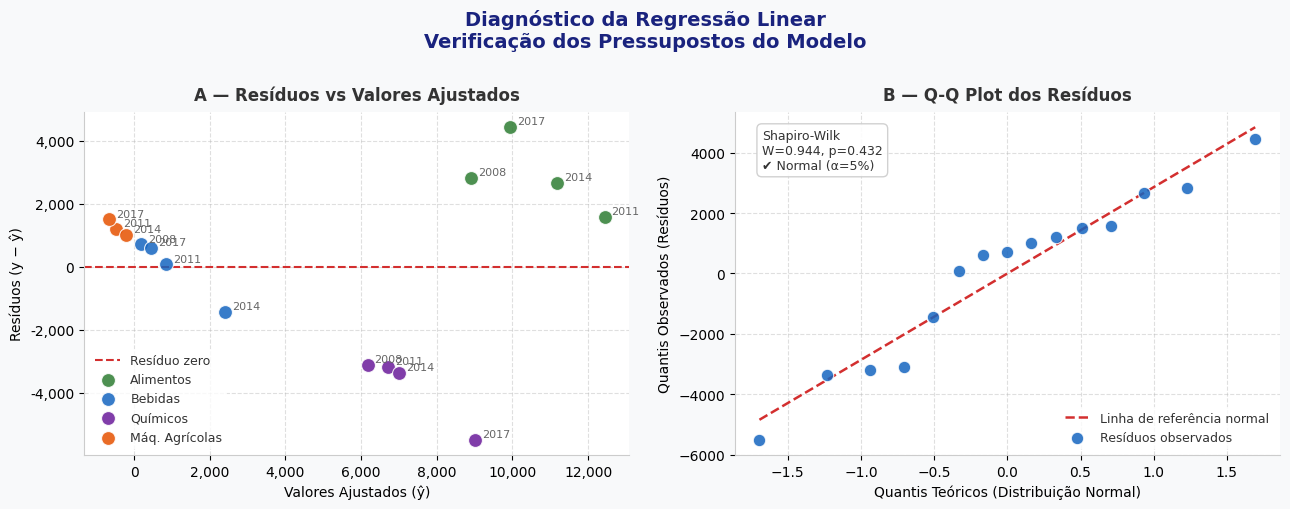

In [6]:
"""
=======================================================================
ANÁLISE PINTEC - Impacto do Investimento em P&D na Adoção de Inovações
no Agronegócio
Dados: IBGE - Pesquisa de Inovação (PINTEC) | Anos: 2008, 2011, 2014, 2017
=======================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import shapiro, probplot
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")

# ── Paleta de cores consistente para os gráficos ──────────────────────
CORES = ["#2E7D32", "#1565C0", "#6A1B9A", "#E65100"]
ANOS  = [2008, 2011, 2014, 2017]

# =======================================================================
# 1. CARREGAMENTO E LIMPEZA DOS DADOS
# =======================================================================

def carregar_tabela(caminho, nome_coluna_valor):
    """
    Lê um CSV do PINTEC (separador ';', BOM UTF-8) e retorna um
    DataFrame limpo com colunas: ['setor', 2008, 2011, 2014, 2017].
    """
    with open(caminho, encoding="utf-8-sig") as f:
        linhas = f.readlines()

    # Detecta automaticamente onde os dados começam:
    # procura a linha com os anos e começa a ler a partir da seguinte.
    inicio = 5
    for i, linha in enumerate(linhas):
        if '"2008"' in linha and '"2017"' in linha:
            inicio = i + 1
            break

    dados_brutos = []
    for linha in linhas[inicio:]:
        linha = linha.strip()
        if not linha or linha.startswith('"Fonte'):
            break
        partes = [p.strip('"') for p in linha.split(";")]
        if len(partes) >= 5:
            dados_brutos.append(partes[:5])

    df = pd.DataFrame(dados_brutos, columns=["setor", "2008", "2011", "2014", "2017"])

    for ano in ["2008", "2011", "2014", "2017"]:
        df[ano] = (
            df[ano]
            .replace({"...": np.nan, "-": np.nan, "..": np.nan, "X": np.nan})
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )
        df = df.rename(columns={ano: int(ano)})

    apelidos = {
        "10 FABRICAÇÃO DE PRODUTOS ALIMENTÍCIOS":
            "Alimentos",
        "11 FABRICAÇÃO DE BEBIDAS":
            "Bebidas",
        "20 FABRICAÇÃO DE PRODUTOS QUÍMICOS":
            "Químicos",
        "28.3 Fabricação de tratores e de máquinas e equipamentos para a agricultura e pecuária":
            "Máq. Agrícolas",
    }
    df["setor"] = df["setor"].map(apelidos).fillna(df["setor"])
    return df


df_empresas   = carregar_tabela("tabela5453.csv", "n_empresas")
df_dispendios = carregar_tabela("tabela5464.csv", "dispendio_mil_reais")

print("✔  Dados carregados com sucesso.")
print("\n── Nº de empresas com inovação ──")
print(df_empresas.to_string(index=False))
print("\n── Dispêndios em inovação (Mil R$) ──")
print(df_dispendios.to_string(index=False))


# =======================================================================
# 2. MONTAGEM DO DATAFRAME ANALÍTICO (formato longo)
# =======================================================================

def wide_para_long(df, nome_variavel):
    return df.melt(
        id_vars="setor",
        value_vars=ANOS,
        var_name="ano",
        value_name=nome_variavel
    )

long_emp = wide_para_long(df_empresas,   "n_empresas")
long_dis = wide_para_long(df_dispendios, "dispendio_mil_reais")

painel = pd.merge(long_emp, long_dis, on=["setor", "ano"])
painel["ano"] = painel["ano"].astype(int)
painel = painel.dropna()

print(f"\n── Painel analítico ({len(painel)} observações) ──")
print(painel.to_string(index=False))


# =======================================================================
# 3. ESTATÍSTICA DESCRITIVA
# =======================================================================
print("\n" + "="*60)
print("3. ESTATÍSTICA DESCRITIVA")
print("="*60)

desc_emp = painel.groupby("setor")["n_empresas"].describe().round(1)
desc_dis = painel.groupby("setor")["dispendio_mil_reais"].describe().round(1)

print("\nNº de empresas inovadoras por setor:")
print(desc_emp[["mean", "std", "min", "max"]].rename(
    columns={"mean": "Média", "std": "Desvio-P.", "min": "Mínimo", "max": "Máximo"}
))

print("\nDispêndios (Mil R$) por setor:")
print(desc_dis[["mean", "std", "min", "max"]].rename(
    columns={"mean": "Média", "std": "Desvio-P.", "min": "Mínimo", "max": "Máximo"}
))


# =======================================================================
# 4. CAGR — TAXA DE CRESCIMENTO ANUAL COMPOSTA
# =======================================================================
# O CAGR responde: "se o crescimento fosse constante, qual seria a taxa
# anual equivalente ao crescimento total observado no período?"
# Fórmula: CAGR = (Valor_final / Valor_inicial)^(1/n_anos) - 1
# Usamos 2011→2017 (6 anos) para incluir Máq. Agrícolas, que não tem 2008.
# =======================================================================
print("\n" + "="*60)
print("4. CAGR — TAXA DE CRESCIMENTO ANUAL COMPOSTA (2011 → 2017)")
print("="*60)

def calcular_cagr(df_wide, coluna_label, ano_ini=2011, ano_fim=2017):
    """
    Recebe o DataFrame no formato largo (colunas = anos),
    calcula o CAGR entre ano_ini e ano_fim e imprime o resultado.
    Retorna um dict {setor: cagr_percentual}.
    """
    n_anos = ano_fim - ano_ini
    resultados = {}
    print(f"\n{'Setor':<20} {'Valor '+str(ano_ini):>15} {'Valor '+str(ano_fim):>15} {'CAGR':>8}")
    print("-" * 62)
    for _, row in df_wide.iterrows():
        v_ini = row[ano_ini]
        v_fim = row[ano_fim]
        if pd.isna(v_ini) or pd.isna(v_fim) or v_ini == 0:
            print(f"  {row['setor']:<18}  {'N/D':>15} {'N/D':>15} {'N/D':>8}")
            continue
        cagr = (v_fim / v_ini) ** (1 / n_anos) - 1
        resultados[row["setor"]] = cagr * 100
        print(f"  {row['setor']:<18}  {v_ini:>15,.0f} {v_fim:>15,.0f} {cagr*100:>7.2f}%")
    return resultados

print(f"\n  [Nº de Empresas Inovadoras]")
cagr_empresas = calcular_cagr(df_empresas, "Empresas")

print(f"\n  [Dispêndios em Inovação (Mil R$)]")
cagr_dispendios = calcular_cagr(df_dispendios, "Dispêndios")


# =======================================================================
# 5. CORRELAÇÃO DE PEARSON
# =======================================================================
print("\n" + "="*60)
print("5. CORRELAÇÃO DE PEARSON  (dispêndio ↔ nº empresas inovadoras)")
print("="*60)

r, p = stats.pearsonr(painel["dispendio_mil_reais"], painel["n_empresas"])
print(f"\n  Coeficiente r = {r:.4f}")
print(f"  Valor-p       = {p:.4f}")
if p < 0.05:
    print("  → Correlação SIGNIFICATIVA ao nível de 5%.")
else:
    print("  → Correlação não significativa ao nível de 5%.")

print("\nCorrelação por setor:")
for setor, grupo in painel.groupby("setor"):
    if len(grupo) >= 3:
        r_s, p_s = stats.pearsonr(grupo["dispendio_mil_reais"], grupo["n_empresas"])
        sig = "✔ sig." if p_s < 0.05 else "—"
        print(f"  {setor:<18}  r = {r_s:+.4f}  p = {p_s:.4f}  {sig}")


# =======================================================================
# 6. REGRESSÃO LINEAR SIMPLES
# =======================================================================
print("\n" + "="*60)
print("6. REGRESSÃO LINEAR SIMPLES")
print("   Variável dependente   : Nº de empresas inovadoras")
print("   Variável independente : Dispêndio em inovação (Mil R$)")
print("="*60)

X = painel[["dispendio_mil_reais"]].values
y = painel["n_empresas"].values

modelo = LinearRegression()
modelo.fit(X, y)
y_pred = modelo.predict(X)
residuos = y - y_pred          # resíduos = diferença entre real e previsto

r2   = r2_score(y, y_pred)
incl = modelo.coef_[0]
orig = modelo.intercept_

slope, intercept, r_val, p_val, stderr = stats.linregress(
    painel["dispendio_mil_reais"], painel["n_empresas"]
)

print(f"\n  Equação : Nº_empresas = {orig:.2f} + {incl:.6f} × Dispêndio")
print(f"  R²       = {r2:.4f}  ({r2*100:.1f}% da variância explicada)")
print(f"  Coef. β₁ = {incl:.6f}  (p = {p_val:.4f})")
print(f"  Intercepto β₀ = {orig:.2f}")

if p_val < 0.05:
    print("  → Coeficiente SIGNIFICATIVO: o investimento prevê inovação.")
else:
    print("  → Coeficiente não significativo ao nível de 5%.")

print(f"\n  Interpretação prática:")
print(f"  A cada R$ 1 bilhão investido em inovação, estima-se um acréscimo")
print(f"  de {incl * 1_000_000:.0f} empresas adotando inovações no setor.")


# =======================================================================
# 7. DIAGNÓSTICO DA REGRESSÃO
# =======================================================================
# Antes de confiar nos resultados da regressão, precisamos verificar se
# seus pressupostos são atendidos. Os principais são:
#
#   a) Normalidade dos resíduos  → testada com Shapiro-Wilk
#      Se os resíduos não são normais, os p-valores da regressão perdem
#      confiabilidade. Hipótese nula (H₀): os resíduos são normais.
#
#   b) Homocedasticidade         → inspecionada visualmente
#      Os resíduos devem ter variância constante ao longo dos valores
#      ajustados (sem "cone" ou padrão). Violação = heterocedasticidade.
#
#   c) Ausência de tendência     → gráfico resíduos vs ajustados
#      Não deve haver padrão sistemático nos resíduos; devem estar
#      dispersos aleatoriamente em torno de zero.
# =======================================================================
print("\n" + "="*60)
print("7. DIAGNÓSTICO DA REGRESSÃO")
print("="*60)

# ── 7a. Teste de Shapiro-Wilk ─────────────────────────────────────────
stat_sw, p_sw = shapiro(residuos)
print(f"\n  Teste de Shapiro-Wilk (normalidade dos resíduos):")
print(f"    W = {stat_sw:.4f}  |  p = {p_sw:.4f}")
if p_sw > 0.05:
    print("    → H₀ NÃO rejeitada: resíduos compatíveis com normalidade (α=5%).")
    print("    ✔ Pressuposto de normalidade ATENDIDO.")
else:
    print("    → H₀ REJEITADA: resíduos não normais (α=5%).")
    print("    ⚠  Pressuposto de normalidade VIOLADO — interpretar com cautela.")

# ── 7b. Estatísticas descritivas dos resíduos ─────────────────────────
print(f"\n  Estatísticas dos resíduos:")
print(f"    Média   : {residuos.mean():.4f}  (esperado ≈ 0)")
print(f"    Desvio  : {residuos.std():.2f}")
print(f"    Mín/Máx : {residuos.min():.2f} / {residuos.max():.2f}")

# ── 7c. Homocedasticidade — correlação de Spearman entre |resíduos| e ŷ
# Se |resíduos| cresce com ŷ, temos heterocedasticidade.
rho, p_rho = stats.spearmanr(np.abs(residuos), y_pred)
print(f"\n  Teste de Homocedasticidade (Spearman |resíduos| vs ŷ):")
print(f"    ρ = {rho:.4f}  |  p = {p_rho:.4f}")
if p_rho > 0.05:
    print("    ✔ Sem evidência de heterocedasticidade (α=5%).")
else:
    print("    ⚠  Possível heterocedasticidade detectada.")


# =======================================================================
# 8. VISUALIZAÇÕES
# =======================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color']  = '#333333'

setores = painel["setor"].unique()

# ── FIGURA 1: Análise principal (4 gráficos) ──────────────────────────
fig1, axes = plt.subplots(2, 2, figsize=(15, 11), facecolor='#F8F9FA')
fig1.suptitle(
    "Análise PINTEC – Investimento em P&D e Inovação no Agronegócio\n"
    "Indicadores de Impacto Setorial • Fonte: IBGE (2008–2017)",
    fontsize=16, fontweight="bold", y=0.98, color='#1A237E'
)

# ── Gráfico 1: Evolução do Nº de empresas inovadoras ──────────────────
ax1 = axes[0, 0]
for i, setor in enumerate(setores):
    sub = painel[painel["setor"] == setor].sort_values("ano")
    ax1.plot(sub["ano"], sub["n_empresas"], marker="o", label=setor,
             color=CORES[i], linewidth=2.5, markersize=7)
ax1.set_title("Evolução do Nº de Empresas Inovadoras", fontweight="bold", fontsize=12, pad=10)
ax1.set_xlabel("Ano", fontsize=10)
ax1.set_ylabel("Nº de Empresas", fontsize=10)
ax1.set_xticks(ANOS)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.5)

# ── Gráfico 2: Evolução dos Dispêndios ────────────────────────────────
ax2 = axes[0, 1]
for i, setor in enumerate(setores):
    sub = painel[painel["setor"] == setor].sort_values("ano")
    ax2.plot(sub["ano"], sub["dispendio_mil_reais"] / 1_000,
             marker="s", label=setor, color=CORES[i], linewidth=2.5, markersize=6)
ax2.set_title("Evolução dos Dispêndios em Inovação", fontweight="bold", fontsize=12, pad=10)
ax2.set_xlabel("Ano", fontsize=10)
ax2.set_ylabel("Dispêndio (Milhões de R$)", fontsize=10)
ax2.set_xticks(ANOS)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}M"))
ax2.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=9)
ax2.grid(True, linestyle="--", alpha=0.5)

# ── Gráfico 3: Dispersão com linha de regressão ───────────────────────
ax3 = axes[1, 0]
for i, setor in enumerate(setores):
    sub = painel[painel["setor"] == setor]
    ax3.scatter(
        sub["dispendio_mil_reais"] / 1_000, sub["n_empresas"],
        label=setor, color=CORES[i], s=120, zorder=3,
        alpha=0.9, edgecolors='white', linewidth=1
    )
    for _, row in sub.iterrows():
        ax3.annotate(str(row["ano"]),
                     (row["dispendio_mil_reais"] / 1_000, row["n_empresas"]),
                     textcoords="offset points", xytext=(6, -2),
                     fontsize=8, color='#555555', weight='bold')

x_range = np.linspace(painel["dispendio_mil_reais"].min(),
                      painel["dispendio_mil_reais"].max(), 100)
y_range = modelo.predict(x_range.reshape(-1, 1))
ax3.plot(x_range / 1_000, y_range, "--", color="#D32F2F", linewidth=1.8,
         label=f"Tendência Linear (R²={r2:.2f})", zorder=2)
ax3.set_title("Dispersão: Dispêndio × Empresas Inovadoras", fontweight="bold", fontsize=12, pad=10)
ax3.set_xlabel("Dispêndio (Milhões de R$)", fontsize=10)
ax3.set_ylabel("Nº de Empresas", fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}M"))
ax3.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=9, loc='upper left')
ax3.grid(True, linestyle="--", alpha=0.5)

# ── Gráfico 4: CAGR por setor (Dispêndios 2011→2017) ─────────────────
# Substituímos o gráfico de barras 2011 vs 2017 pelo CAGR,
# que comunica crescimento de forma mais direta num artigo científico.
ax4 = axes[1, 1]
setores_cagr = list(cagr_dispendios.keys())
valores_cagr = list(cagr_dispendios.values())
cores_cagr   = [CORES[i] for i, s in enumerate(setores) if s in setores_cagr]

bars = ax4.bar(setores_cagr, valores_cagr, color=cores_cagr,
               edgecolor='grey', linewidth=0.5, alpha=0.9)

# Anotação do valor em cima de cada barra
for bar, val in zip(bars, valores_cagr):
    offset = 0.08 if val >= 0 else -0.08
    va     = 'bottom' if val >= 0 else 'top'
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + offset,
             f"{val:.1f}%", ha='center', va=va,
             fontsize=10, fontweight='bold', color='#333333')

ax4.set_title("CAGR dos Dispêndios em Inovação\n(2011 → 2017)",
              fontweight="bold", fontsize=12, pad=10)
ax4.set_ylabel("CAGR (% a.a.)", fontsize=10)
# Eixo Y com margem acima e abaixo para mostrar barras negativas
margem = max(abs(v) for v in valores_cagr) * 0.35
ax4.set_ylim(min(valores_cagr) - margem, max(valores_cagr) + margem)
ax4.axhline(0, color='#888888', linewidth=0.9, linestyle='-')  # linha de referência no zero
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax4.grid(axis="y", linestyle="--", alpha=0.5)

for ax in axes.flat:
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig("graficos_pintec_principal.png", dpi=300, bbox_inches="tight")
print("\n✔ Figura 1 salva: graficos_pintec_principal.png")


# ── FIGURA 2: Diagnóstico da Regressão (2 gráficos) ───────────────────
# Esta figura vai direto na seção de resultados do artigo para mostrar
# que os pressupostos da regressão foram verificados.
fig2, (ax_res, ax_qq) = plt.subplots(1, 2, figsize=(13, 5), facecolor='#F8F9FA')
fig2.suptitle(
    "Diagnóstico da Regressão Linear\n"
    "Verificação dos Pressupostos do Modelo",
    fontsize=14, fontweight="bold", y=1.01, color='#1A237E'
)

# ── Gráfico A: Resíduos vs Valores Ajustados ──────────────────────────
# O que esperar: pontos dispersos aleatoriamente ao redor de y=0,
# sem padrão em forma de leque ou curva. Isso indica homocedasticidade
# e ausência de não-linearidade não capturada pelo modelo.
ax_res.axhline(0, color='#D32F2F', linewidth=1.5, linestyle='--', label='Resíduo zero')
for i, setor in enumerate(setores):
    idx = painel["setor"] == setor
    ax_res.scatter(y_pred[idx], residuos[idx],
                   color=CORES[i], s=100, label=setor,
                   alpha=0.85, edgecolors='white', linewidth=0.8, zorder=3)
    # Anota o ano de cada ponto para rastreabilidade
    for j, (yp, res) in enumerate(zip(y_pred[idx], residuos[idx])):
        ano_ponto = painel[idx]["ano"].values[j]
        ax_res.annotate(str(ano_ponto), (yp, res),
                        textcoords="offset points", xytext=(5, 2),
                        fontsize=8, color='#666666')

ax_res.set_title("A — Resíduos vs Valores Ajustados",
                 fontweight="bold", fontsize=12, pad=8)
ax_res.set_xlabel("Valores Ajustados (ŷ)", fontsize=10)
ax_res.set_ylabel("Resíduos (y − ŷ)", fontsize=10)
ax_res.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax_res.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax_res.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=9)
ax_res.grid(True, linestyle="--", alpha=0.4)

# ── Gráfico B: Q-Q Plot ────────────────────────────────────────────────
# O que esperar: os pontos devem seguir a linha diagonal tracejada.
# Desvios nas extremidades indicam caudas mais pesadas (não-normalidade).
# Este gráfico complementa o teste de Shapiro-Wilk com visualização.
(osm, osr), (slope_qq, intercept_qq, r_qq) = probplot(residuos, dist="norm")
ax_qq.plot(osm, intercept_qq + slope_qq * np.array(osm),
           "--", color='#D32F2F', linewidth=1.8, label='Linha de referência normal')
ax_qq.scatter(osm, osr, color='#1565C0', s=80,
              alpha=0.85, edgecolors='white', linewidth=0.8, zorder=3,
              label='Resíduos observados')

# Adiciona anotação com o resultado do Shapiro-Wilk
sw_texto = (f"Shapiro-Wilk\nW={stat_sw:.3f}, p={p_sw:.3f}\n"
            f"{'✔ Normal (α=5%)' if p_sw > 0.05 else '⚠ Não-normal (α=5%)'}")
ax_qq.text(0.05, 0.95, sw_texto, transform=ax_qq.transAxes,
           fontsize=9, verticalalignment='top',
           bbox=dict(facecolor='white', edgecolor='#CCCCCC',
                     boxstyle='round,pad=0.4', alpha=0.9))

ax_qq.set_title("B — Q-Q Plot dos Resíduos",
                fontweight="bold", fontsize=12, pad=8)
ax_qq.set_xlabel("Quantis Teóricos (Distribuição Normal)", fontsize=10)
ax_qq.set_ylabel("Quantis Observados (Resíduos)", fontsize=10)
ax_qq.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=9)
ax_qq.grid(True, linestyle="--", alpha=0.4)

for ax in (ax_res, ax_qq):
    ax.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.savefig("graficos_pintec_diagnostico.png", dpi=300, bbox_inches="tight")
print("✔ Figura 2 salva: graficos_pintec_diagnostico.png")


# =======================================================================
# 9. SUMÁRIO PARA O ARTIGO
# =======================================================================
print("\n" + "="*60)
print("9. SUMÁRIO PARA O ARTIGO CIENTÍFICO (SIMPEP)")
print("="*60)

# Setor de maior CAGR de dispêndios
setor_maior_cagr = max(cagr_dispendios, key=cagr_dispendios.get)

print(f"""
Título sugerido:
  Investimento em P&D e Adoção de Inovações no Agronegócio:
  Uma Análise a partir da PINTEC (2008–2017)

Principais achados:
  • Setor de maior dispêndio médio:
    {desc_dis['mean'].idxmax()} ({desc_dis['mean'].max():,.0f} Mil R$)

  • Setor com maior nº médio de empresas inovadoras:
    {desc_emp['mean'].idxmax()} ({desc_emp['mean'].max():,.0f} empresas)

  • CAGR dos dispêndios 2011→2017:
""")
for setor, cagr in cagr_dispendios.items():
    print(f"    {setor:<20} {cagr:.2f}% a.a.")

print(f"""
  • Correlação geral (Pearson):
    r = {r:.4f} | p = {p:.4f} → {"Significativa" if p < 0.05 else "Não-significativa"} (α=5%)

  • Regressão Linear:
    R² = {r2:.4f} | Coef. = {incl:.4e}
    A cada R$ 1 bi investido → {incl * 1_000_000:.0f} empresas adicionais inovando

  • Diagnóstico da Regressão:
    Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f}
    → Resíduos {"normais" if p_sw > 0.05 else "não-normais"} (α=5%) — 
      {"modelo válido para inferência." if p_sw > 0.05 else "interpretar resultados com cautela."}
    Homocedasticidade: Spearman ρ={rho:.4f}, p={p_rho:.4f}
    → {"Variância constante dos resíduos." if p_rho > 0.05 else "Possível heterocedasticidade."}
""")

print("Análise concluída! ✔")